In [1]:
import sys, pathlib, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(pathlib.Path.cwd().parent))
from src.normalize import extract_brand_and_body_style

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

with open("../config/config.yaml") as f:
    cfg = yaml.safe_load(f)
with open("../config/brands.yaml") as f:
    brand_config = yaml.safe_load(f)

In [2]:
cleaned = pd.read_csv("../" + cfg["paths"]["clean"])

brand_parts = cleaned["brand_model"].apply(lambda x: extract_brand_and_body_style(x, brand_config))
df = pd.concat([cleaned, brand_parts], axis=1)
df["log_price"] = np.log(df["asking_price"])

print("shape:", df.shape)
df.head()

shape: (1626, 32)


,token,title,publish_date,city,district,url,description,mileage,year_raw,color,...,year_jalali,year_gregorian,price_corrected,price_original_raw,price_flag_extreme_high,mileage_flag_high,brand,is_pickup,brand_matched,log_price
0,gapduKJt,رانا پلاس دیسک_کاسه_مدل ۱۴۰۵_صفر تحویل فوری,2026-07-30 12:34:00,تهران,صادقیه,https://divar.ir/v/gapduKJt,⚪️صنعت خودروی جباری بیش از ۱۵سال سابقه کار⚪️\n...,۰,۱۴۰۵ - ۲۰۲۶,سفید,...,1405.0,2026.0,False,NaN,False,False,رانا,False,False,21.250949
1,gaQegi2Y,بستیون T77 _سانتافه.اپتیما.توسان_نقدواقساط,2026-08-28 20:19:00,تهران,نارمک,https://divar.ir/v/gaQegi2Y,سلام ماشین بشدت تمییز و لازرورق بدون حتی یک نق...,۱۸۰۰۰,۱۴۰۲ - ۲۰۲۳,کربن بلک,...,1402.0,2023.0,False,NaN,False,False,بستیون,False,False,22.298112
2,gaoq_MK2,ماشین ۱۱۱ تمیز,2026-09-15 11:26:00,تهران,ولنجک,https://divar.ir/v/gaoq_MK2,ماشین تمیز بی رنگ مناسب مصرف کننده عکس کارشناس...,۱۴۰۰۰۰,۱۳۹۲ - ۲۰۱۳,سفید,...,1392.0,2013.0,False,NaN,False,False,پراید,False,False,20.408555
3,game0bJc,تویوتا کرولا کراس نیوفیس2026,2026-09-13 10:19:00,تهران,اباذر,https://divar.ir/v/game0bJc,**گروه خودرویی ستوده با بیش از ده شعبه فعال**\...,۰,۲۰۲۶,سفید,...,1405.0,2026.0,False,NaN,False,False,تویوتا,False,False,22.808938
4,gaR02TC9,نیسان زامیاد_ دوگانه_تک اکستند EX صفرتحویل فوری,2026-05-23 12:35:00,تهران,شهرآرا,https://divar.ir/v/gaR02TC9,مارال خودرو ( عاملیت مجاز خودروهای داخلی و خار...,۰,۱۴۰۵ - ۲۰۲۶,سفید,...,1405.0,2026.0,False,NaN,False,False,زامیاد,False,False,21.411400


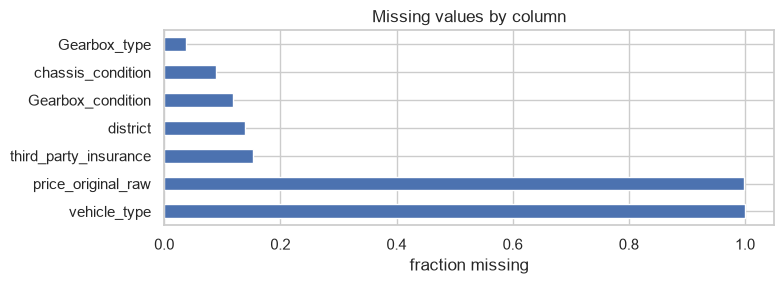

vehicle_type             1.000000
price_original_raw       0.998770
third_party_insurance    0.153137
district                 0.139606
Gearbox_condition        0.118696
chassis_condition        0.088561
Gearbox_type             0.037515
dtype: float64


In [ ]:
# 1. Missingness overview
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(missing))))
missing.plot(kind="barh", ax=ax)
ax.set_xlabel("fraction missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()

print(missing)



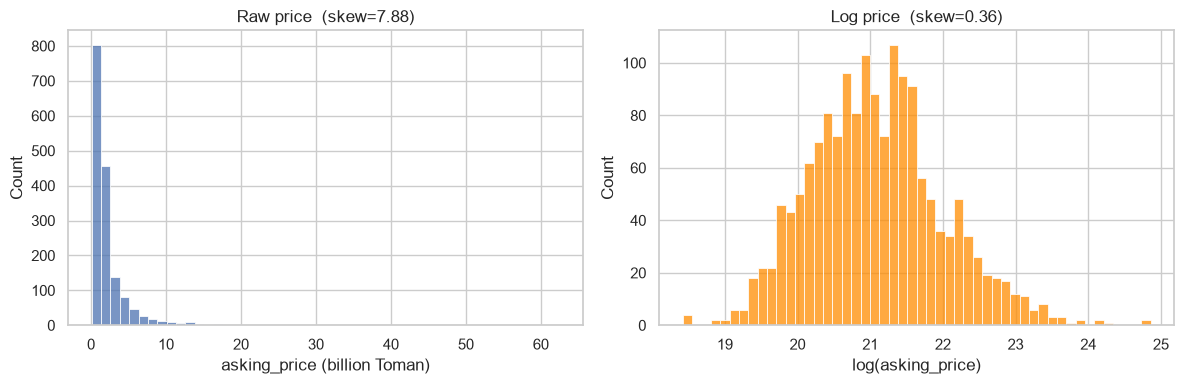

count    1.626000e+03
mean     2.293500e+09
std      3.452845e+09
min      1.000000e+08
25%      7.515000e+08
50%      1.350000e+09
75%      2.396500e+09
max      6.250000e+10
Name: asking_price, dtype: float64


In [ ]:
# 2. Price distribution: raw vs log
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["asking_price"] / 1e9, bins=50, ax=axes[0])
axes[0].set_xlabel("asking_price (billion Toman)")
axes[0].set_title(f"Raw price  (skew={df['asking_price'].skew():.2f})")

sns.histplot(df["log_price"], bins=50, ax=axes[1], color="darkorange")
axes[1].set_xlabel("log(asking_price)")
axes[1].set_title(f"Log price  (skew={df['log_price'].skew():.2f})")
plt.tight_layout()
plt.show()

print(df["asking_price"].describe())

Correlation with asking_price:
asking_price      1.000000
year_gregorian    0.311455
mileage_km       -0.308880
Name: asking_price, dtype: float64

Correlation with log_price:
log_price         1.000000
year_gregorian    0.632006
mileage_km       -0.561428
Name: log_price, dtype: float64


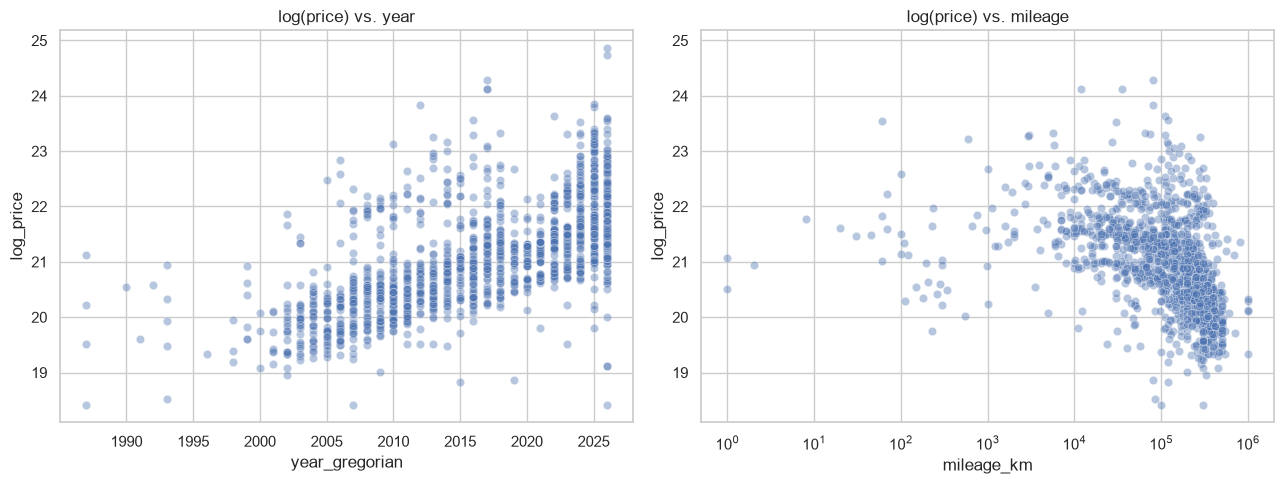

In [ ]:
# 3. Price vs. year and mileage
print("Correlation with asking_price:")
print(df[["asking_price", "year_gregorian", "mileage_km"]].corr()["asking_price"])
print()
print("Correlation with log_price:")
print(df[["log_price", "year_gregorian", "mileage_km"]].corr()["log_price"])

# %%
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="year_gregorian", y="log_price", alpha=0.4, ax=axes[0])
axes[0].set_title("log(price) vs. year")

sns.scatterplot(data=df, x="mileage_km", y="log_price", alpha=0.4, ax=axes[1])
axes[1].set_title("log(price) vs. mileage")
axes[1].set_xscale("log")
plt.tight_layout()
plt.show()

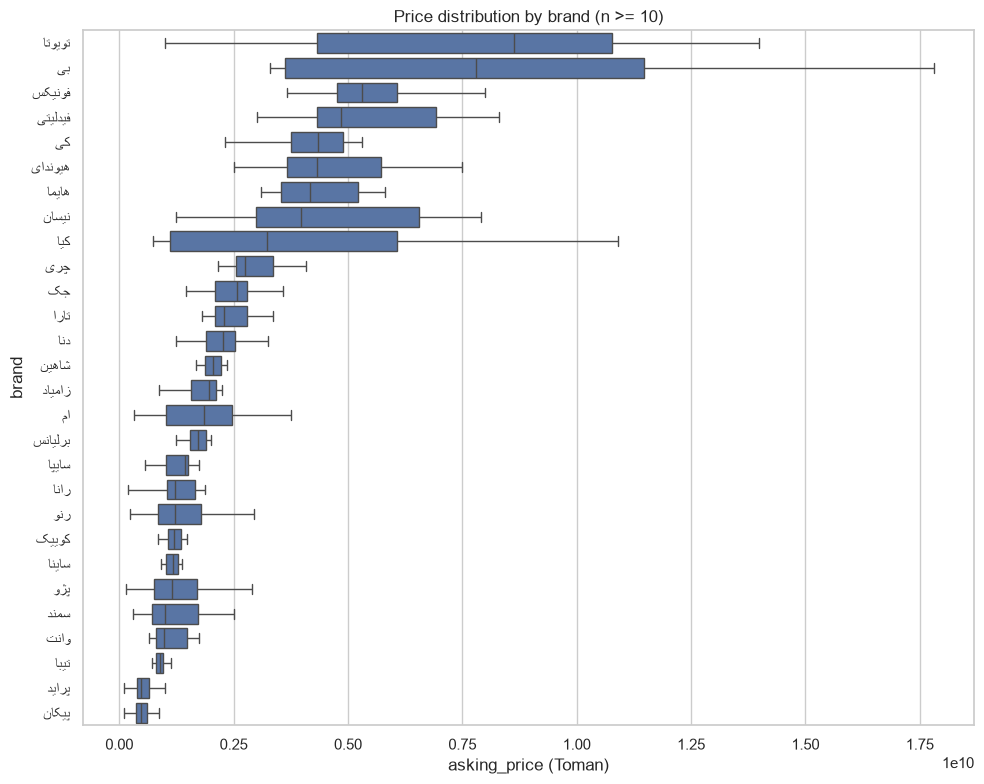

           n        median           p25           p75
brand                                                 
تویوتا    36  8.625000e+09  4.325000e+09  1.077250e+10
بی        12  7.800000e+09  3.625000e+09  1.146250e+10
فونیکس    33  5.298000e+09  4.750000e+09  6.080000e+09
فیدلیتی   10  4.850000e+09  4.322500e+09  6.922500e+09
کی        34  4.350000e+09  3.760000e+09  4.887500e+09
هیوندای   38  4.325000e+09  3.662500e+09  5.720000e+09
هایما     14  4.175000e+09  3.537500e+09  5.212500e+09
نیسان     17  3.980000e+09  2.990000e+09  6.550000e+09
کیا       16  3.220000e+09  1.112500e+09  6.075000e+09
چری       14  2.750000e+09  2.550000e+09  3.362500e+09
جک        26  2.565000e+09  2.097500e+09  2.787500e+09
تارا      31  2.290000e+09  2.092500e+09  2.790000e+09
دنا       61  2.270000e+09  1.900000e+09  2.520000e+09
شاهین     29  2.045000e+09  1.865000e+09  2.228000e+09
زامیاد    20  1.970000e+09  1.572500e+09  2.112500e+09
ام        63  1.860000e+09  1.027500e+09  2.472500e+09
برلیانس   

In [ ]:
# 4. Price by brand
MIN_N = 10
brand_counts = df["brand"].value_counts()
common_brands = brand_counts[brand_counts >= MIN_N].index

brand_order = (
    df[df["brand"].isin(common_brands)]
    .groupby("brand")["asking_price"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(
    data=df[df["brand"].isin(common_brands)],
    x="asking_price", y="brand",
    order=brand_order, ax=ax, showfliers=False,
)
ax.set_xlabel("asking_price (Toman)")
ax.set_title(f"Price distribution by brand (n >= {MIN_N})")
plt.tight_layout()
plt.show()

brand_summary = (
    df[df["brand"].isin(common_brands)]
    .groupby("brand")["asking_price"]
    .agg(n="count", median="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
    .sort_values("median", ascending=False)
)
print(brand_summary)

city
تهران     490
کرج       236
اصفهان    229
مشهد      229
تبریز     227
شیراز     213
شهریار      1
پردیس       1
Name: count, dtype: int64

Cities excluded for n < 10: {'پردیس', 'شهریار'}

          n        median
city                     
تهران   490  2.040000e+09
شیراز   213  1.520000e+09
کرج     236  1.205000e+09
اصفهان  229  1.180000e+09
مشهد    229  1.140000e+09
تبریز   227  9.700000e+08


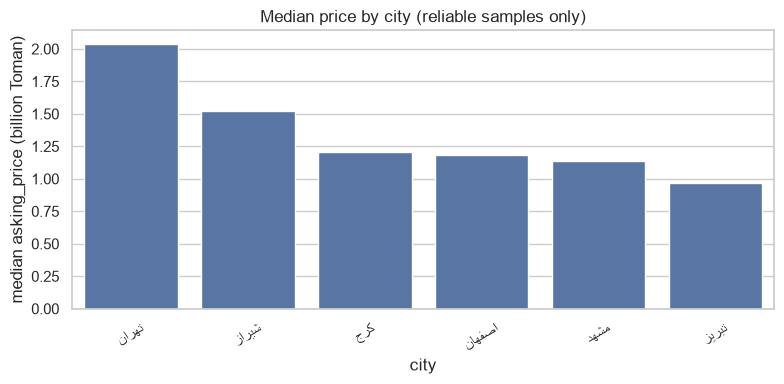

In [7]:
# 5. Price by city
MIN_N_CITY = 10
city_counts = df["city"].value_counts()
print(city_counts)

common_cities = city_counts[city_counts >= MIN_N_CITY].index
city_summary = (
    df[df["city"].isin(common_cities)]
    .groupby("city")["asking_price"]
    .agg(n="count", median="median")
    .sort_values("median", ascending=False)
)
print()
print(f"Cities excluded for n < {MIN_N_CITY}:", set(city_counts.index) - set(common_cities))
print()
print(city_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=city_summary.index, y=city_summary["median"] / 1e9, ax=ax)
ax.set_ylabel("median asking_price (billion Toman)")
ax.set_title("Median price by city (reliable samples only)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

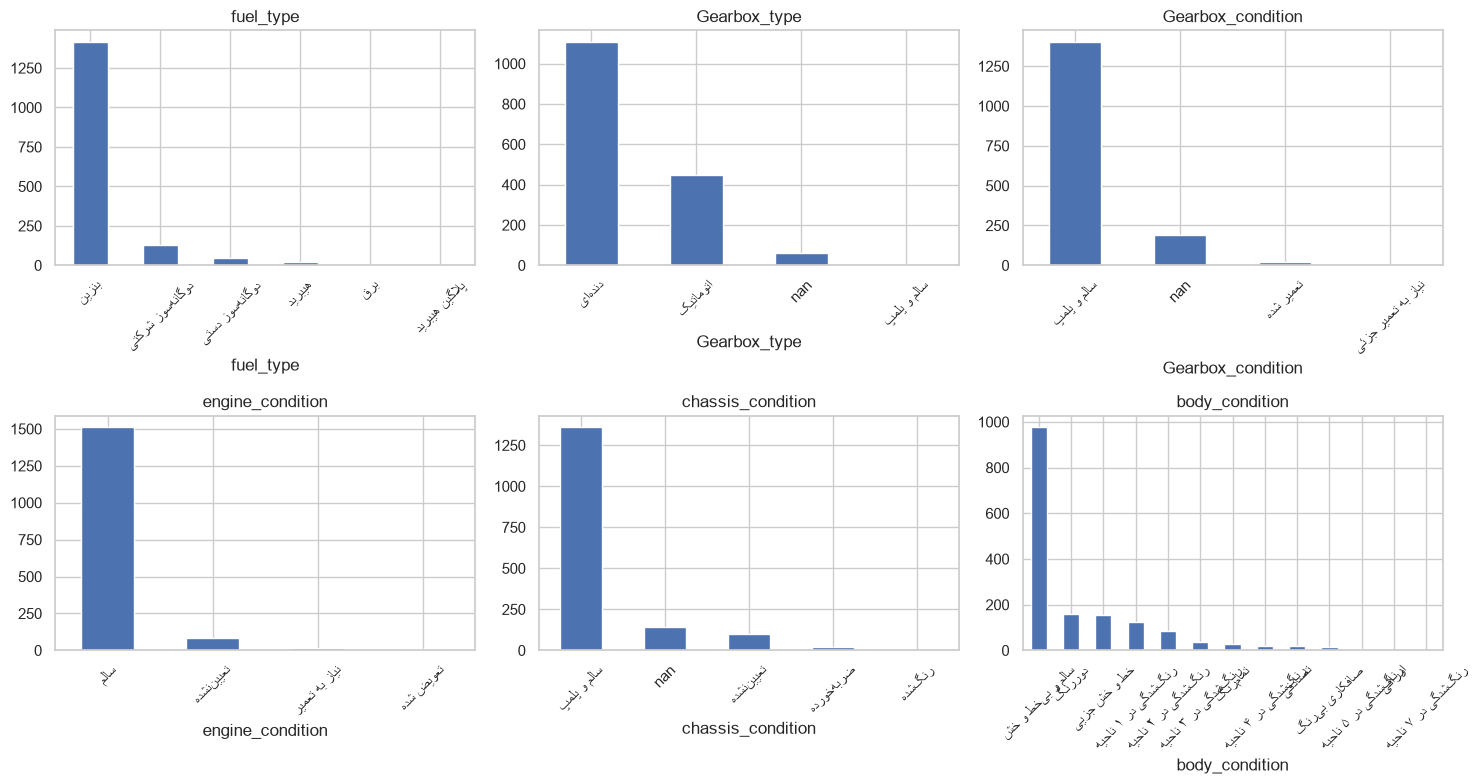

In [8]:
# 6. Categorical field distributions
cat_cols = ["fuel_type", "Gearbox_type", "Gearbox_condition",
            "engine_condition", "chassis_condition", "body_condition"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cat_cols):
    if col in df.columns:
        df[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# 7. Pickup flag and price
print(df.groupby("is_pickup")["asking_price"].agg(n="count", median="median"))

              n        median
is_pickup                    
False      1626  1.350000e+09


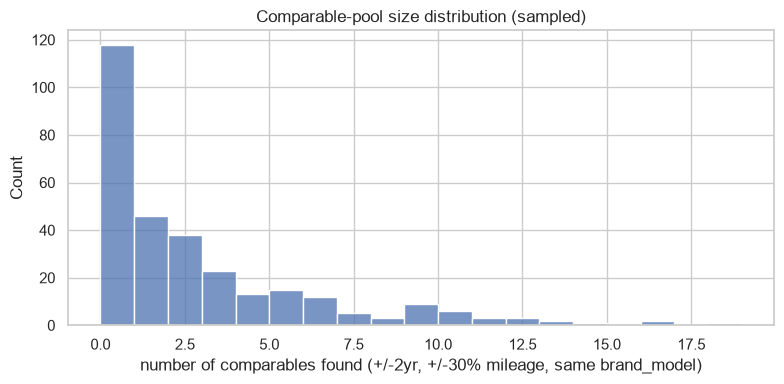

count    300.000000
mean       2.496667
std        3.412056
min        0.000000
25%        0.000000
50%        1.000000
75%        3.250000
max       18.000000
Name: n_comparables, dtype: float64

share of listings with ZERO same-model comparables: 0.3933333333333333


In [10]:
# 8. Comparable-vehicle availability
def count_comparables(row, data, year_window=2, mileage_pct=0.3):
    same_model = data[data["brand_model"] == row["brand_model"]]
    year_ok = (same_model["year_gregorian"] - row["year_gregorian"]).abs() <= year_window
    mileage_ok = (same_model["mileage_km"] - row["mileage_km"]).abs() <= mileage_pct * max(row["mileage_km"], 1)
    return (year_ok & mileage_ok).sum() - 1  # exclude the row itself

sample = df.sample(min(300, len(df)), random_state=42)  # subsample: O(n^2) if run on full data
sample = sample.copy()
sample["n_comparables"] = sample.apply(lambda r: count_comparables(r, df), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(sample["n_comparables"], bins=range(0, sample["n_comparables"].max() + 2), ax=ax)
ax.set_xlabel("number of comparables found (+/-2yr, +/-30% mileage, same brand_model)")
ax.set_title("Comparable-pool size distribution (sampled)")
plt.tight_layout()
plt.show()

print(sample["n_comparables"].describe())
print()
print("share of listings with ZERO same-model comparables:",
      (sample["n_comparables"] == 0).mean())

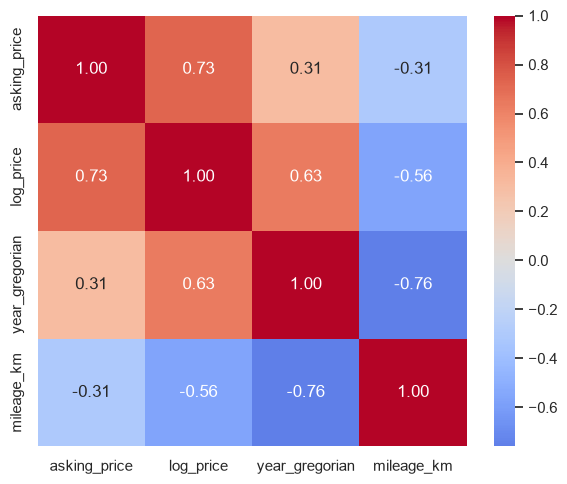

Rows with corrected extreme prices:
                     brand_model  asking_price  price_original_raw
9          فیدلیتی پرستیژ 7 نفره  8.100000e+09        8.100000e+12
1269  رنو تندر 90 (L90 لوگان) E1  1.250000e+09        1.250000e+12

Rows still flagged high (unresolved) / high mileage:
  price_flag_extreme_high: 0
  mileage_flag_high: 6


In [11]:
# 9. Correlation matrix (numeric features)
numeric_cols = ["asking_price", "log_price", "year_gregorian", "mileage_km", "insurance_months_left"]
numeric_cols = [c for c in numeric_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 10. Corrected / flagged rows -- spot check

# %%
print("Rows with corrected extreme prices:")
print(df[df.get("price_corrected", False) == True][["brand_model", "asking_price", "price_original_raw"]])

print()
print("Rows still flagged high (unresolved) / high mileage:")
flag_cols = [c for c in ["price_flag_extreme_high", "mileage_flag_high"] if c in df.columns]
for c in flag_cols:
    print(f"  {c}: {df[c].sum()}")